# House Price Estimator — Training Notebook

Trains a regression model on the California Housing dataset
(StatLib / scikit-learn) to predict median house value from
basic property and location features. The trained model backs
the "Price Estimator" tool in the Rehaish app.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

## 1. Load data

20,640 California block groups from the 1990 census. Target
`MedHouseVal` is median house value in units of $100,000.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 2. Exploratory data analysis

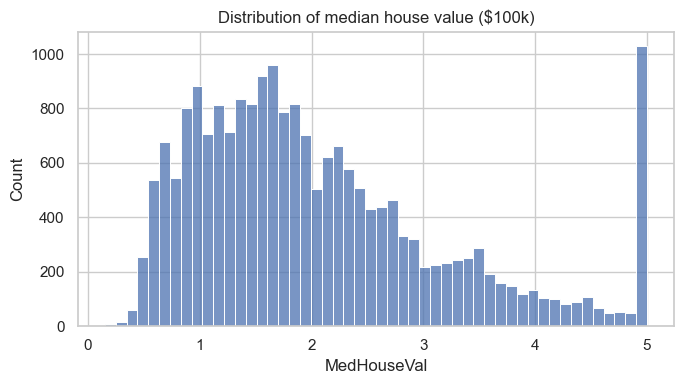

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df["MedHouseVal"], bins=50, ax=ax)
ax.set_title("Distribution of median house value ($100k)")
fig.tight_layout()
fig.savefig("../model/eda_target_distribution.png", dpi=120)
plt.show()

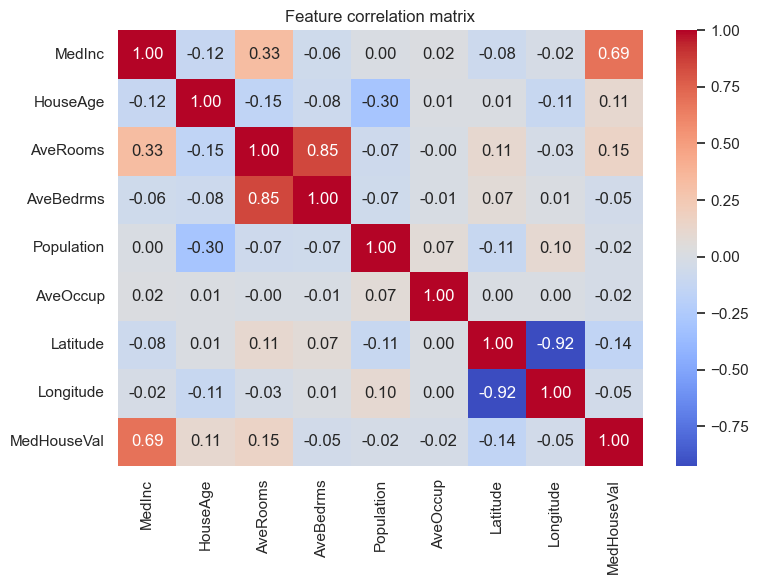

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Feature correlation matrix")
fig.tight_layout()
fig.savefig("../model/eda_correlation.png", dpi=120)
plt.show()

`MedInc` (median income) is the strongest single predictor of
`MedHouseVal`, as expected. Latitude/longitude capture the
well-known SF Bay Area / LA coastal price premium.

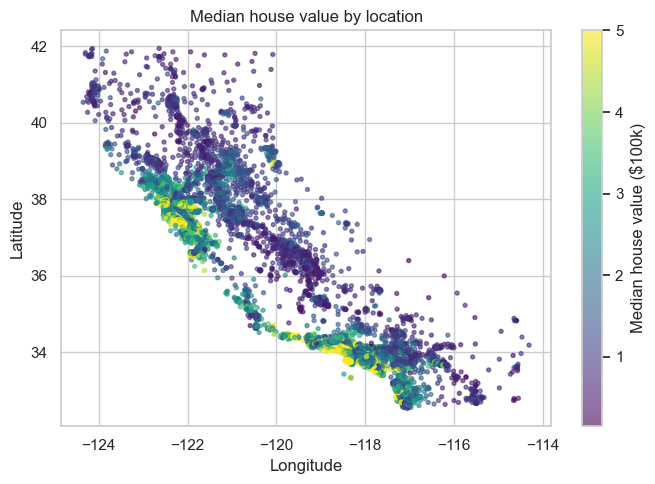

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    df["Longitude"], df["Latitude"], c=df["MedHouseVal"], cmap="viridis", s=8, alpha=0.6
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Median house value by location")
fig.colorbar(scatter, label="Median house value ($100k)")
fig.tight_layout()
fig.savefig("../model/eda_geo_prices.png", dpi=120)
plt.show()

## 3. Train / test split

In [6]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (16512, 8), Test: (4128, 8)


## 4. Baseline: Linear Regression

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Linear Regression")
print(f"  MAE:  {mean_absolute_error(y_test, lr_pred):.3f}")
print(f"  RMSE: {root_mean_squared_error(y_test, lr_pred):.3f}")
print(f"  R^2:  {r2_score(y_test, lr_pred):.3f}")

Linear Regression
  MAE:  0.533
  RMSE: 0.746
  R^2:  0.576


## 5. Random Forest Regressor

In [8]:
rf = RandomForestRegressor(
    n_estimators=100, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest")
print(f"  MAE:  {mean_absolute_error(y_test, rf_pred):.3f}")
print(f"  RMSE: {root_mean_squared_error(y_test, rf_pred):.3f}")
print(f"  R^2:  {r2_score(y_test, rf_pred):.3f}")

Random Forest
  MAE:  0.343
  RMSE: 0.521
  R^2:  0.793


Random Forest clearly outperforms the linear baseline — the
relationship between location/income and price is non-linear,
which a tree ensemble captures much better.

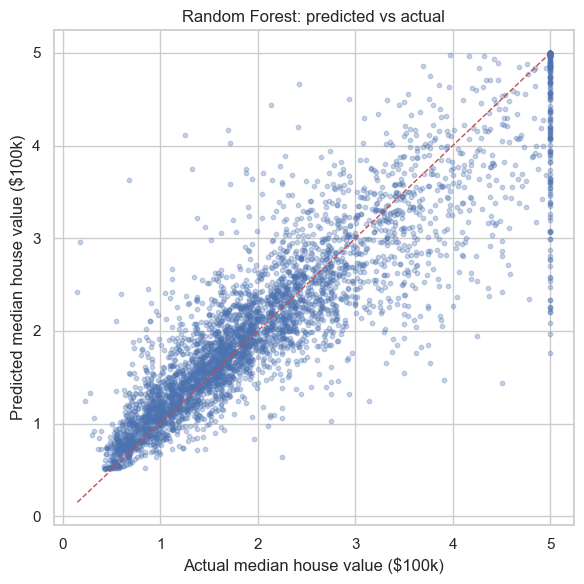

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, rf_pred, alpha=0.3, s=10)
ax.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=1)
ax.set_xlabel("Actual median house value ($100k)")
ax.set_ylabel("Predicted median house value ($100k)")
ax.set_title("Random Forest: predicted vs actual")
fig.tight_layout()
fig.savefig("../model/eda_pred_vs_actual.png", dpi=120)
plt.show()

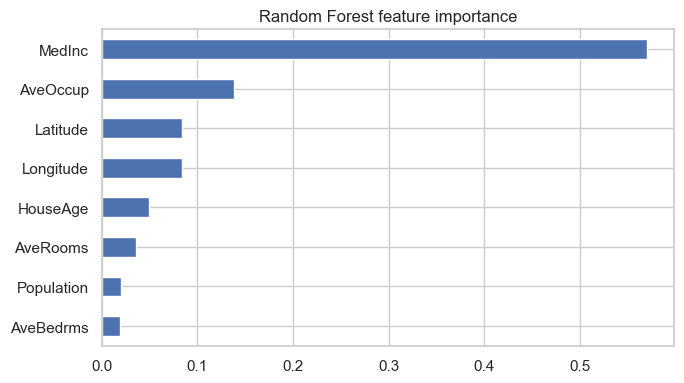

In [10]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax)
ax.set_title("Random Forest feature importance")
fig.tight_layout()
fig.savefig("../model/eda_feature_importance.png", dpi=120)
plt.show()

## 6. Save the model

The Random Forest is the better model — it's what the
`/predict` API serves.

In [11]:
joblib.dump(rf, "../model/price_model.joblib", compress=3)
joblib.dump(list(X.columns), "../model/feature_order.joblib")

import os
size_mb = os.path.getsize("../model/price_model.joblib") / (1024 * 1024)
print(f"Saved model + feature order to ml-price-estimator/model/ ({size_mb:.1f} MB)")

Saved model + feature order to ml-price-estimator/model/ (5.3 MB)
